In [2]:
import supervision as sv
from ultralytics.models.sam import SAM3SemanticPredictor
from ultralytics import YOLO, SAM
import torch
import cv2
import matplotlib.pyplot as plt
import urllib.request
from pathlib import Path

Path("assets").mkdir(exist_ok=True)
urllib.request.urlretrieve("https://ultralytics.com/images/bus.jpg",    "assets/bus.jpg")
urllib.request.urlretrieve("https://ultralytics.com/images/zidane.jpg", "assets/zidane.jpg")

image = cv2.imread("assets/bus.jpg")
print(f"Imagen cargada: {image.shape}")


Imagen cargada: (1080, 810, 3)


In [3]:
overrides = dict(conf=0.25, task="segment", mode="predict", model="sam3.pt")
if torch.cuda.is_available():
    overrides["half"] = True   # FP16 solo en GPU

predictor = SAM3SemanticPredictor(overrides=overrides)
print("Predictor listo")


Predictor listo


In [4]:
predictor.set_image(image)

resultados = predictor(text=["person"])[0]
detections = sv.Detections.from_ultralytics(resultados)

print(f"Objetos encontrados: {len(detections)}")
print(f"¿Tiene máscaras?    {detections.mask is not None}")


Ultralytics 8.4.56  Python-3.11.15 torch-2.12.0+cpu CPU (12th Gen Intel Core i5-1235U)
requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
  Cloning https://github.com/ultralytics/CLIP.git to C:\Users\m0nda\AppData\Local\Temp\pip-req-build-temh9brx
  Running command git clone --filter=blob:none --quiet https://github.com/ultralytics/CLIP.git 'C:\Users\m0nda\AppData\Local\Temp\pip-req-build-temh9brx'
  Resolved https://github.com/ultralytics/CLIP.git to commit 81ff68ed7ffcac3b40484c914f104f816757308d
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1383260 sha256=544c89585a60c2

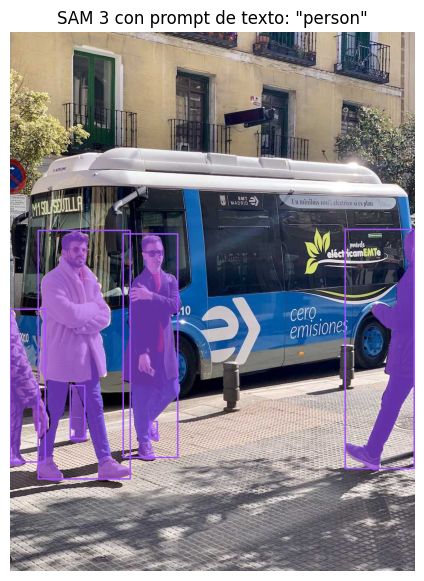

In [5]:
box_annotator  = sv.BoxAnnotator()
mask_annotator = sv.MaskAnnotator(opacity=0.6)

annotated = mask_annotator.annotate(scene=image.copy(), detections=detections)
annotated = box_annotator.annotate(scene=annotated,    detections=detections)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title('SAM 3 con prompt de texto: "person"')
plt.show()


In [6]:
if detections.confidence is not None:
    for i, conf in enumerate(detections.confidence):
        area = int(detections.mask[i].sum()) if detections.mask is not None else 0
        print(f"Objeto {i}: confianza={conf:.3f}  area={area:,} px2")


Objeto 0: confianza=0.972  area=31,806 px2
Objeto 1: confianza=0.970  area=45,028 px2
Objeto 2: confianza=0.966  area=20,826 px2
Objeto 3: confianza=0.943  area=11,310 px2
Objeto 4: confianza=0.762  area=2,757 px2
Objeto 5: confianza=0.302  area=535 px2



0: 644x644 1 vehicle, 2362.3ms
Speed: 10.3ms preprocess, 2362.3ms inference, 17.9ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\m0nda\Visual Studio\Projects\futbot\notebooks\runs\segment\predict

0: 644x644 1 bus, 2090.9ms
Speed: 11.7ms preprocess, 2090.9ms inference, 5.0ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\m0nda\Visual Studio\Projects\futbot\notebooks\runs\segment\predict

0: 644x644 6 persons, 2161.6ms
Speed: 14.2ms preprocess, 2161.6ms inference, 18.0ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\m0nda\Visual Studio\Projects\futbot\notebooks\runs\segment\predict


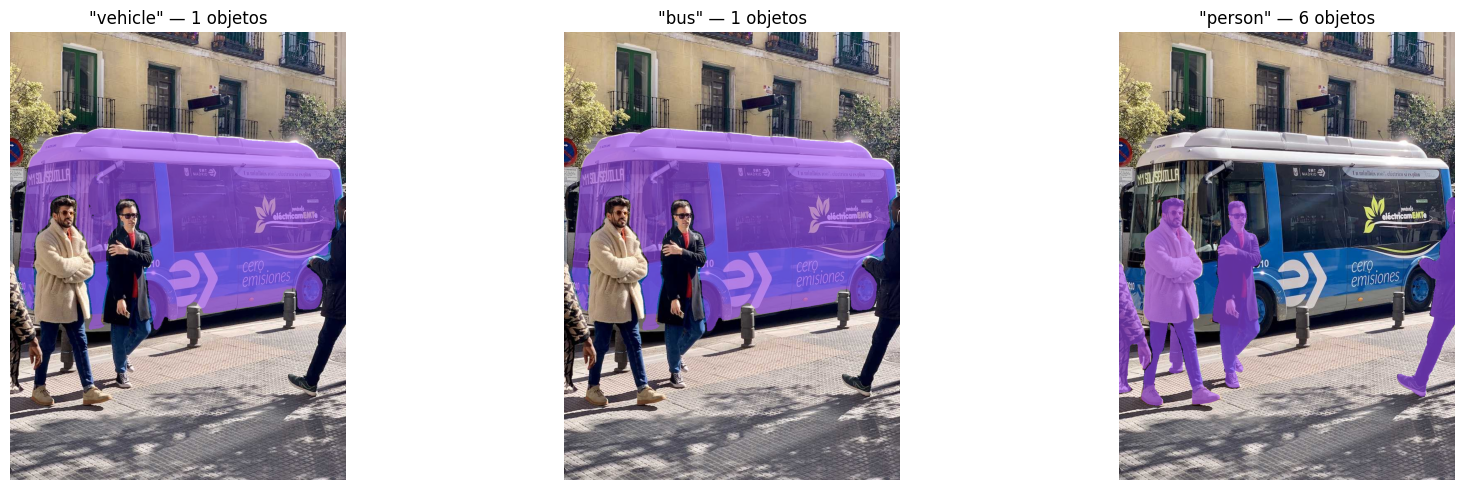

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, concepto in zip(axes, ["vehicle", "bus", "person"]):
    res = predictor(text=[concepto])[0]
    det = sv.Detections.from_ultralytics(res)
    scn = sv.MaskAnnotator(opacity=0.6).annotate(scene=image.copy(), detections=det)
    ax.imshow(cv2.cvtColor(scn, cv2.COLOR_BGR2RGB))
    ax.set_title(f'"{concepto}" — {len(det)} objetos')
    ax.axis("off")
plt.tight_layout()
plt.show()
# 💭 Reflexión: ¿"vehicle" incluye el bus? ¿Qué ocurre con conceptos ambiguos?
# Conceptos amplios capturan más instancias pero pueden incluir falsos positivos.



0: 644x644 13 persons, 2017.2ms
Speed: 26.2ms preprocess, 2017.2ms inference, 36.4ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\m0nda\Visual Studio\Projects\futbot\notebooks\runs\segment\predict

0: 644x644 6 persons, 1822.9ms
Speed: 12.4ms preprocess, 1822.9ms inference, 16.2ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\m0nda\Visual Studio\Projects\futbot\notebooks\runs\segment\predict

0: 644x644 5 persons, 1455.3ms
Speed: 7.5ms preprocess, 1455.3ms inference, 10.9ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\m0nda\Visual Studio\Projects\futbot\notebooks\runs\segment\predict


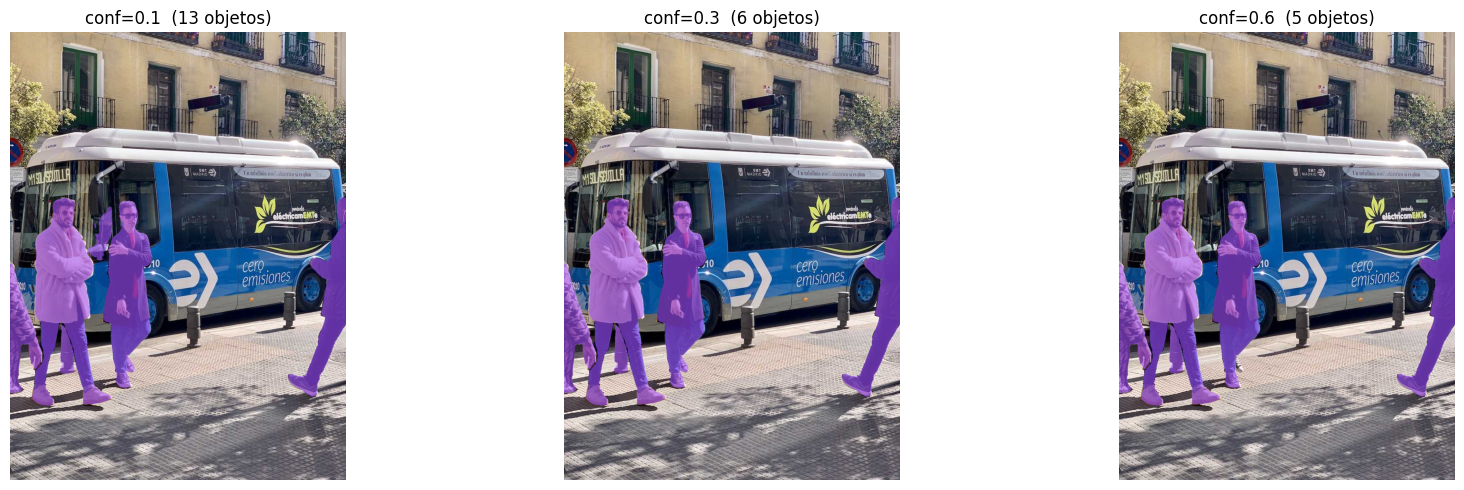

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, umbral in zip(axes, [0.1, 0.3, 0.6]):
    predictor.args.conf = umbral
    res = predictor(text=["person"])[0]
    det = sv.Detections.from_ultralytics(res)
    scn = sv.MaskAnnotator(opacity=0.6).annotate(scene=image.copy(), detections=det)
    ax.imshow(cv2.cvtColor(scn, cv2.COLOR_BGR2RGB))
    ax.set_title(f"conf={umbral}  ({len(det)} objetos)")
    ax.axis("off")
plt.tight_layout()
plt.show()
predictor.args.conf = 0.25   # restaurar valor original
# 💭 Reflexión: ¿Qué umbral produce el mejor resultado visual?
# Un umbral bajo puede incluir detecciones parciales en los bordes de la imagen.



0: 644x644 6 persons, 3353.2ms
Speed: 25.7ms preprocess, 3353.2ms inference, 23.1ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\m0nda\Visual Studio\Projects\futbot\notebooks\runs\segment\predict
Detections(xyxy=array([[     56.375,      397.96,       240.5,      895.99]], dtype=float32), mask=array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]], shape=(1, 1080, 810)), confidence=array([    0.97013], dtype=float32), class_id=array([0]), tracker_id=None, data={'class_name': array(['person'], dtype='<U6')}, metadata={})

0: 644x644 1 bus, 2930.9ms
Speed: 11.3ms preprocess, 2930.9ms inference, 11.9ms postprocess per image at shape (1, 3, 644, 644)
Results saved 

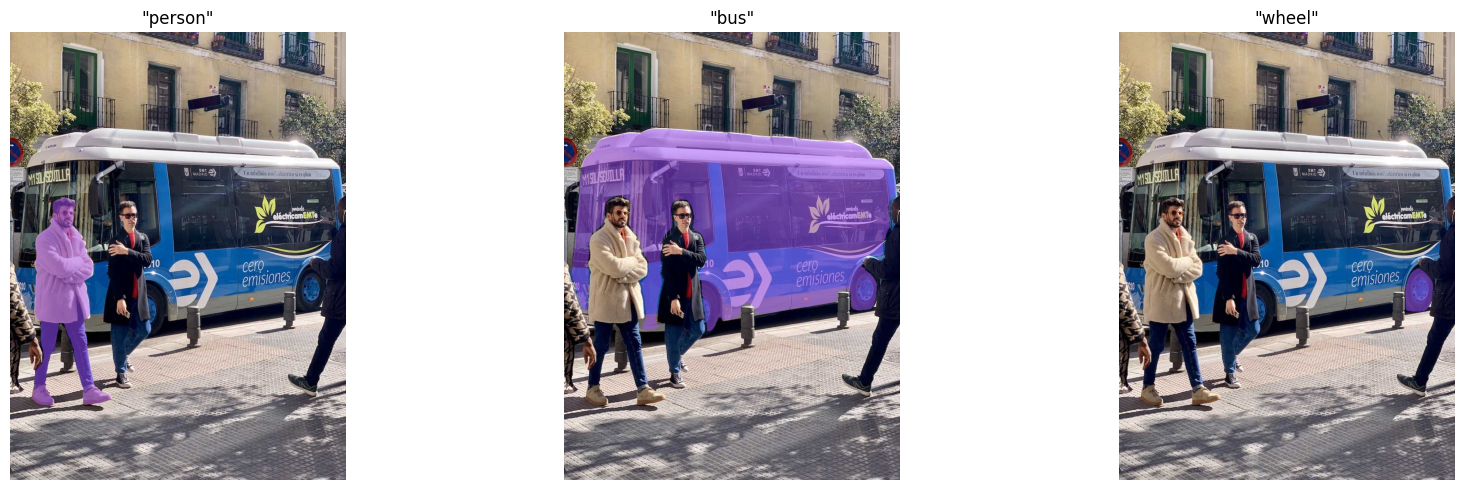

In [17]:
mask_annotator = sv.MaskAnnotator()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, concepto in zip(axes, ["person", "bus", "wheel"]):
    res = predictor(text=[concepto])[0]
    det = sv.Detections.from_ultralytics(res)
    if det.mask is not None and len(det) > 0:
        areas   = det.mask.sum(axis=(1, 2))   
        idx_max = int(areas.argmax())          # índice del objeto más grande
        mayor   = det[idx_max]                 # sv.Detections con 1 objeto
        print(mayor)
        annotated = mask_annotator.annotate(scene=image.copy(), detections=mayor)
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(f'"{concepto}"')
        ax.axis("off")
plt.tight_layout()
plt.show()